# Разведочный анализ данных

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", "{:.4f}".format)

TARGET = "salary_mean_net"
ID_COL = "id"


def find_project_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd / "3_vacancies"]
    candidates.extend(cwd.parents)
    candidates.extend(parent / "3_vacancies" for parent in cwd.parents)

    seen = set()
    for candidate in candidates:
        try:
            path = candidate.resolve()
        except OSError:
            continue
        if path in seen:
            continue
        seen.add(path)
        if (path / "data" / "train.csv").exists() and (path / "data" / "test_x.csv").exists():
            return path
    raise FileNotFoundError("Не найдена папка проекта с data/train.csv")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test_x.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

text_columns = [
    "name",
    "employer_name",
    "key_skills_name",
    "raw_description",
    "raw_branded_description",
    "lemmaized_wo_stopwords_raw_description",
    "lemmaized_wo_stopwords_raw_branded_description",
    "name_clean",
    "employer_industries",
]
categorical_columns = [
    "experience_name",
    "schedule_name",
    "employment_name",
    "professional_roles_name",
    "specializations_profarea_name",
    "unified_address_region",
    "unified_address_state",
    "unified_address_city",
    "if_foreign_language",
    "is_branded_description",
]

PROJECT_DIR

## 1. Структура данных

In [2]:
overview = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "target_present": [TARGET in train.columns, TARGET in test.columns],
    },
    index=["train", "test"],
)

columns = pd.DataFrame({"column": train.columns.union(test.columns)})
columns = columns.assign(
    train_dtype=columns["column"].map(lambda column: str(train[column].dtype) if column in train else "NaN"),
    test_dtype=columns["column"].map(lambda column: str(test[column].dtype) if column in test else "NaN"),
)

preview_columns = [
    ID_COL,
    "name",
    "professional_roles_name",
    "experience_name",
    "schedule_name",
    "unified_address_region",
    TARGET,
]
test_preview_columns = [column for column in preview_columns if column in test.columns]

display(overview)
display(columns)
display(train[preview_columns].head())
display(test[test_preview_columns].head())

,rows,columns,target_present
train,49051,26,True
test,12263,25,False


,column,train_dtype,test_dtype
0,accept_handicapped,bool,bool
1,accept_kids,bool,bool
2,employer_id,float64,float64
3,employer_industries,object,object
4,employer_name,object,object
5,employment_name,object,object
6,experience_name,object,object
7,id,int64,int64
8,if_foreign_language,object,object
9,is_branded_description,object,object


,id,name,professional_roles_name,experience_name,schedule_name,unified_address_region,salary_mean_net
0,49443602,Помощник в мастерскую (производство кожгалантереи премиум класса),закройщик,Нет опыта,Полный день,Центральный федеральный округ,35000.0000
1,44210403,Сварщик,сварщик,Нет опыта,Вахтовый метод,Приволжский федеральный округ,72500.0000
2,48784801,Специалист службы поддержки пользователей,специалист технической поддержки,Нет опыта,Удаленная работа,Приволжский федеральный округ,11310.0000
3,43126202,Слесарь-ремонтник,сантехник,Нет опыта,Полный день,Центральный федеральный округ,33930.0000
4,41164202,Врач-педиатр участковый (п.Снежный),врач,Нет опыта,Полный день,Дальневосточный федеральный округ,70000.0000


,id,name,professional_roles_name,experience_name,schedule_name,unified_address_region
0,46224201,Менеджер по работе с клиентами,менеджер по продажам,Нет опыта,Полный день,Центральный федеральный округ
1,42119402,Водитель-экспедитор (по доставке товаров до торговых объектов),водитель,От 1 года до 3 лет,Сменный график,Приволжский федеральный округ
2,45716401,"Продавец-кассир (ул. Московский пр-т, д.17)",продавец-консультант,Нет опыта,Полный день,Центральный федеральный округ
3,43716203,Кладовщик,кладовщик,Нет опыта,Полный день,Сибирский федеральный округ
4,47109602,Специалист по обучению персонала,менеджер по персоналу,Нет опыта,Полный день,Центральный федеральный округ


## 2. Пропуски и дубликаты

In [3]:
missing = pd.DataFrame(index=train.columns.union(test.columns))
missing["train_missing"] = train.isna().sum().reindex(missing.index)
missing["train_missing_pct"] = missing["train_missing"] / len(train) * 100
missing["test_missing"] = test.isna().sum().reindex(missing.index)
missing["test_missing_pct"] = missing["test_missing"] / len(test) * 100
missing = missing.fillna(0)
missing = missing.loc[(missing["train_missing"] > 0) | (missing["test_missing"] > 0)]
missing = missing.sort_values(["train_missing_pct", "test_missing_pct"], ascending=False)

duplicates = pd.DataFrame(
    {
        "duplicated_id": [train[ID_COL].duplicated().sum(), test[ID_COL].duplicated().sum()],
        "duplicated_rows": [train.duplicated().sum(), test.duplicated().sum()],
    },
    index=["train", "test"],
)

branded_check = pd.crosstab(
    train["is_branded_description"],
    train["raw_branded_description"].notna(),
    rownames=["is_branded_description"],
    colnames=["raw_branded_description_notna"],
    margins=True,
)

display(missing)
display(duplicates)
display(branded_check)

,train_missing,train_missing_pct,test_missing,test_missing_pct
lemmaized_wo_stopwords_raw_branded_description,45065,91.8738,11278.0000,91.9677
raw_branded_description,45065,91.8738,11278.0000,91.9677
unified_address_city,11507,23.4593,2826.0000,23.0449
employer_id,43,0.0877,11.0000,0.0897
unified_address_region,6,0.0122,1.0000,0.0082


,duplicated_id,duplicated_rows
train,0,0
test,0,0


raw_branded_description_notna,False,True,All
is_branded_description,,,
заполнено,45065,0,45065
не заполнено,0,3986,3986
All,45065,3986,49051


## 3. Описательные статистики

In [4]:
target_stats = train[[TARGET]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
target_stats["skew"] = train[TARGET].skew()

categorical_profile = pd.DataFrame(
    {
        "train_unique": train[categorical_columns].nunique(dropna=True),
        "test_unique": test[categorical_columns].nunique(dropna=True),
        "train_top": train[categorical_columns].mode(dropna=True).iloc[0],
        "test_top": test[categorical_columns].mode(dropna=True).iloc[0],
    }
).sort_values("train_unique", ascending=False)

display(target_stats)
display(categorical_profile)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
salary_mean_net,49051.0000,51094.6886,29617.8031,10931.5500,13485.0000,19500.0000,30000.0000,42920.0000,64000.0000,110000.0000,150000.0000,195750.0000,1.5283


,train_unique,test_unique,train_top,test_top
unified_address_city,207,202,Москва,Москва
professional_roles_name,145,142,другое,другое
unified_address_state,84,82,Москва,Москва
specializations_profarea_name,29,29,не указано,не указано
unified_address_region,8,8,Центральный федеральный округ,Центральный федеральный округ
schedule_name,5,5,Полный день,Полный день
employment_name,5,4,Полная занятость,Полная занятость
experience_name,4,4,Нет опыта,Нет опыта
if_foreign_language,2,2,Не указано,Не указано
is_branded_description,2,2,заполнено,заполнено


## 4. Выбросы

Критерий: `x < Q1 - 1.5 * IQR` или `x > Q3 + 1.5 * IQR`.

,column,outliers,outliers_pct,lower_bound,upper_bound,min,max
0,salary_mean_net,2105,4.2915,-21000.0000,115000.0000,10931.5500,195750.0000


,id,name,professional_roles_name,unified_address_region,salary_mean_net
1258,46722602,Менеджер по контролю экономики и стратегии (индустриальный холдинг),финансовый контролер,Центральный федеральный округ,195750.0000
6738,49621000,Менеджер проектов,руководитель проектов,Центральный федеральный округ,195750.0000
19204,42424402,Директор по продажам,коммерческий директор (cco),Центральный федеральный округ,195750.0000
17484,47924602,Наставник отдела продаж,менеджер по продажам,Центральный федеральный округ,195750.0000
25010,49477000,Менеджер по продажам автомобилей,мастер-приемщик,Центральный федеральный округ,195750.0000
32379,45713801,Руководитель проектного офиса IT,руководитель группы разработки,Центральный федеральный округ,195750.0000
26415,47223801,Middle/Senior Python разработчик проектов Data Science,программист,Центральный федеральный округ,195750.0000
38935,49471402,Врач-стоматолог-хирург,врач,Южный федеральный округ,195750.0000
35307,47223800,Middle/Senior Python разработчик проектов Data Science,программист,Северо-Западный федеральный округ,195750.0000
18308,41537802,Менеджер по продажам,менеджер по продажам,Северо-Западный федеральный округ,195000.0000


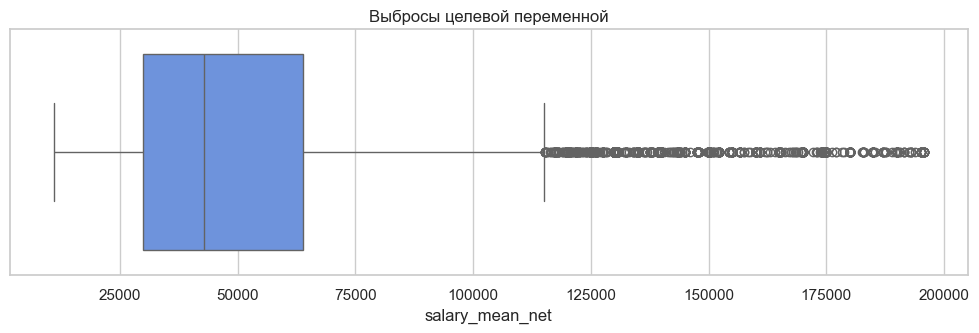

In [5]:
def iqr_outlier_table(values: pd.Series) -> pd.DataFrame:
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (values < lower) | (values > upper)
    return pd.DataFrame(
        {
            "column": [values.name],
            "outliers": [int(mask.sum())],
            "outliers_pct": [mask.mean() * 100],
            "lower_bound": [lower],
            "upper_bound": [upper],
            "min": [values.min()],
            "max": [values.max()],
        }
    )


outlier_table = iqr_outlier_table(train[TARGET])
outlier_mask = train[TARGET] > outlier_table.loc[0, "upper_bound"]
top_outliers = train.loc[
    outlier_mask,
    [ID_COL, "name", "professional_roles_name", "unified_address_region", TARGET],
].sort_values(TARGET, ascending=False).head(10)

display(outlier_table)
display(top_outliers)

plt.figure(figsize=(10, 3.5))
sns.boxplot(x=train[TARGET], color="#5B8DEF")
plt.title("Выбросы целевой переменной")
plt.xlabel(TARGET)
plt.tight_layout()

Boxplot показывает правый хвост распределения зарплат. Наблюдения выше верхней границы IQR соответствуют редким высокооплачиваемым вакансиям; их не следует автоматически считать ошибками данных.

## 5. Целевая переменная

,salary
0.0100,13485.0000
0.0500,19500.0000
0.2500,30000.0000
0.5000,42920.0000
0.7500,64000.0000
0.9500,110000.0000
0.9900,150000.0000


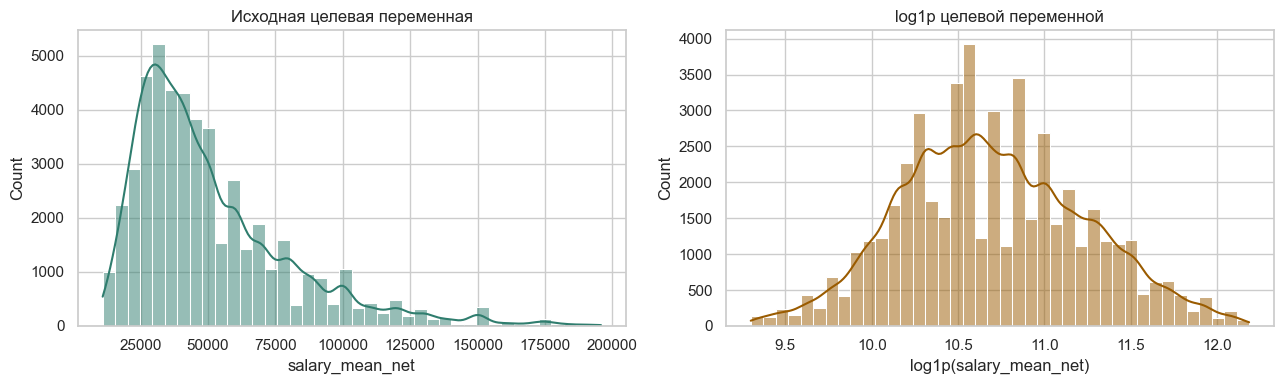

In [6]:
quantiles = train[TARGET].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("salary")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train[TARGET], kde=True, bins=40, ax=axes[0], color="#2F7D6E")
sns.histplot(np.log1p(train[TARGET]), kde=True, bins=40, ax=axes[1], color="#9A5B00")
axes[0].set_title("Исходная целевая переменная")
axes[1].set_title("log1p целевой переменной")
axes[0].set_xlabel(TARGET)
axes[1].set_xlabel(f"log1p({TARGET})")
plt.tight_layout()

display(quantiles)

## 6. Категориальная структура

In [7]:
def total_variation_distance(train_series: pd.Series, test_series: pd.Series) -> float:
    train_share = train_series.fillna("<NA>").value_counts(normalize=True)
    test_share = test_series.fillna("<NA>").value_counts(normalize=True)
    index = train_share.index.union(test_share.index)
    return 0.5 * (train_share.reindex(index, fill_value=0) - test_share.reindex(index, fill_value=0)).abs().sum()


category_rows = []
for column in categorical_columns:
    train_counts = train[column].fillna("<NA>").value_counts(normalize=True)
    test_counts = test[column].fillna("<NA>").value_counts(normalize=True)
    category_rows.append(
        {
            "column": column,
            "train_unique": train[column].nunique(dropna=True),
            "test_unique": test[column].nunique(dropna=True),
            "train_top": train_counts.index[0],
            "train_top_pct": train_counts.iloc[0] * 100,
            "test_top": test_counts.index[0],
            "test_top_pct": test_counts.iloc[0] * 100,
            "tvd": total_variation_distance(train[column], test[column]),
        }
    )

category_shift = pd.DataFrame(category_rows).sort_values("tvd", ascending=False)

selected_distributions = []
for column in ["experience_name", "schedule_name", "unified_address_region", "professional_roles_name"]:
    distribution = train[column].fillna("<NA>").value_counts(normalize=True).head(8).mul(100).rename("train_pct")
    selected_distributions.append(distribution.rename_axis(column).reset_index())

display(category_shift)
for distribution in selected_distributions:
    display(distribution)

,column,train_unique,test_unique,train_top,train_top_pct,test_top,test_top_pct,tvd
7,unified_address_city,207,202,<NA>,23.4593,<NA>,23.0449,0.0408
3,professional_roles_name,145,142,другое,7.6186,другое,7.8855,0.0393
6,unified_address_state,84,82,Москва,16.8233,Москва,16.4479,0.0324
4,specializations_profarea_name,29,29,не указано,68.8222,не указано,68.9880,0.0097
5,unified_address_region,8,8,Центральный федеральный округ,35.0370,Центральный федеральный округ,34.6979,0.0066
1,schedule_name,5,5,Полный день,68.7754,Полный день,69.2816,0.0051
0,experience_name,4,4,Нет опыта,42.8370,Нет опыта,42.5263,0.0032
2,employment_name,5,4,Полная занятость,94.8890,Полная занятость,94.7321,0.0023
9,is_branded_description,2,2,заполнено,91.8738,заполнено,91.9677,0.0009
8,if_foreign_language,2,2,Не указано,97.4598,Не указано,97.4965,0.0004


,experience_name,train_pct
0,Нет опыта,42.8370
1,От 1 года до 3 лет,42.4436
2,От 3 до 6 лет,13.3840
3,Более 6 лет,1.3353


,schedule_name,train_pct
0,Полный день,68.7754
1,Сменный график,15.9100
2,Вахтовый метод,7.2333
3,Удаленная работа,4.0855
4,Гибкий график,3.9958


,unified_address_region,train_pct
0,Центральный федеральный округ,35.0370
1,Приволжский федеральный округ,17.2596
2,Южный федеральный округ,12.2974
3,Северо-Западный федеральный округ,12.2791
4,Сибирский федеральный округ,10.4565
5,Уральский федеральный округ,8.2914
6,Дальневосточный федеральный округ,3.1294
7,Северо-Кавказский федеральный округ,1.2375


,professional_roles_name,train_pct
0,другое,7.6186
1,продавец-консультант,7.5574
2,менеджер по продажам,6.8317
3,водитель,4.9948
4,врач,4.6340
5,бухгалтер,2.7849
6,комплектовщик,2.5015
7,инженер-проектировщик,2.3465


## 7. Связи признаков с зарплатой

,count,median,mean
experience_name,,,
Более 6 лет,655,80000.0000,83357.5693
От 3 до 6 лет,6565,67500.0000,72927.9526
От 1 года до 3 лет,20819,45675.0000,53951.0519
Нет опыта,21012,34800.0000,40437.2456


,count,median,mean
schedule_name,,,
Вахтовый метод,3548,83500.0000,86103.3126
Полный день,33735,42500.0000,49897.4389
Гибкий график,1960,40000.0000,49391.7167
Удаленная работа,2004,40000.0000,56018.0439
Сменный график,7804,35000.0000,39517.2975


,count,median,mean
unified_address_region,,,
Дальневосточный федеральный округ,1535,50000.0000,60848.7560
Центральный федеральный округ,17186,50000.0000,57557.7242
Северо-Западный федеральный округ,6023,45000.0000,52937.7818
Уральский федеральный округ,4067,40000.0000,49899.6581
Сибирский федеральный округ,5129,40000.0000,49870.3403
NaN,6,37400.0000,38650.0000
Приволжский федеральный округ,8466,35000.0000,45025.0708
Северо-Кавказский федеральный округ,607,34800.0000,42007.2901
Южный федеральный округ,6032,32500.0000,39650.5242


,count,median,mean
if_foreign_language,,,
Указано,1246,55285.5000,65879.3175
Не указано,47805,42500.0000,50709.3388


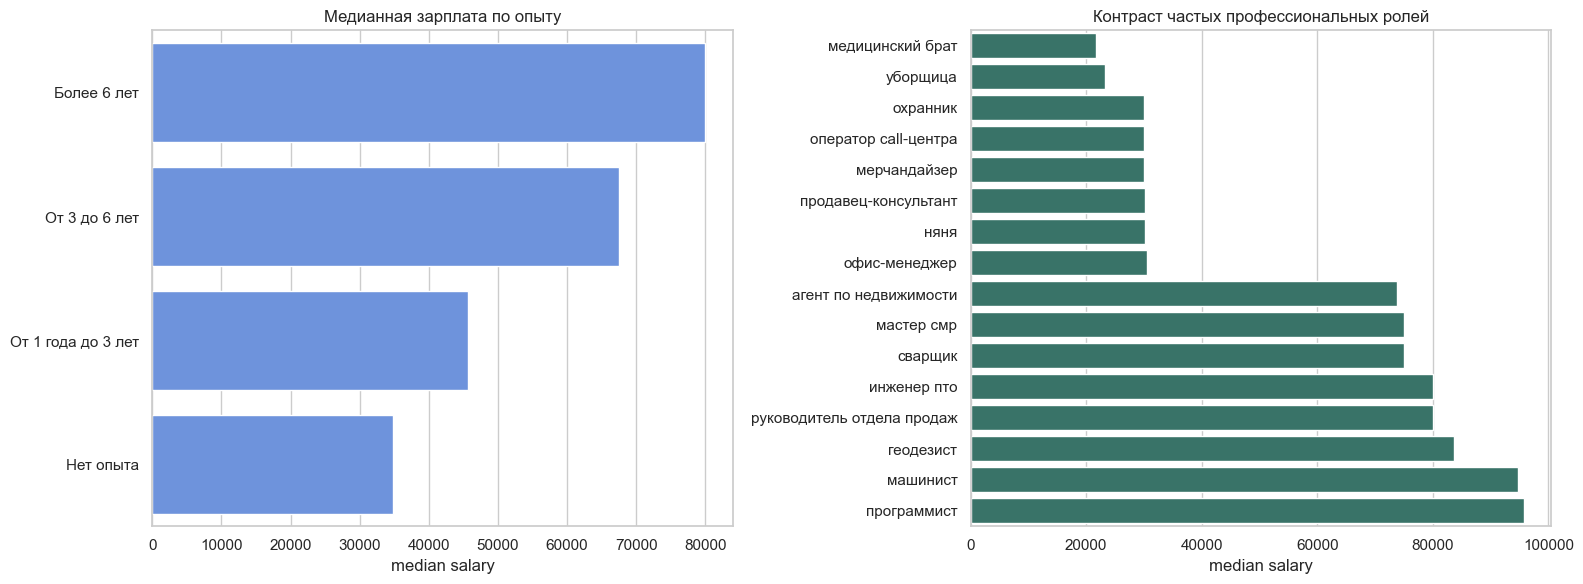

In [8]:
def salary_table(column: str, min_count: int = 1) -> pd.DataFrame:
    table = train.groupby(column, dropna=False)[TARGET].agg(["count", "median", "mean"])
    table = table.loc[table["count"] >= min_count]
    return table.sort_values("median", ascending=False)


salary_experience = salary_table("experience_name")
salary_schedule = salary_table("schedule_name")
salary_region = salary_table("unified_address_region")
salary_language = salary_table("if_foreign_language")
salary_roles = salary_table("professional_roles_name", min_count=100)

display(salary_experience)
display(salary_schedule)
display(salary_region)
display(salary_language)

role_plot = pd.concat([salary_roles.head(8), salary_roles.tail(8)]).drop_duplicates()
role_plot = role_plot.sort_values("median").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=salary_experience.reset_index(),
    x="median",
    y="experience_name",
    ax=axes[0],
    color="#5B8DEF",
)
axes[0].set_title("Медианная зарплата по опыту")
axes[0].set_xlabel("median salary")
axes[0].set_ylabel("")

sns.barplot(
    data=role_plot,
    x="median",
    y="professional_roles_name",
    ax=axes[1],
    color="#2F7D6E",
)
axes[1].set_title("Контраст частых профессиональных ролей")
axes[1].set_xlabel("median salary")
axes[1].set_ylabel("")
plt.tight_layout()

Левая часть показывает рост медианной зарплаты вместе с требуемым опытом. Правая часть сравнивает частые профессиональные роли: технические, инженерные и высококвалифицированные роли имеют более высокие медианы, массовые сервисные роли — более низкие.

## 8. Текстовые поля

,count,mean,std,min,25%,50%,75%,95%,99%,max
raw_description_chars,49051.0000,1106.7802,718.5701,102.0000,598.0000,960.0000,1446.0000,2423.0000,3464.0000,9520.0000
raw_description_words,49051.0000,137.9510,90.1677,1.0000,73.0000,119.0000,181.0000,308.0000,433.0000,1236.0000
name_words,49051.0000,3.4039,2.0946,1.0000,2.0000,3.0000,5.0000,7.0000,10.0000,16.0000
skills_count,49051.0000,0.6745,0.4927,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,6.0000
has_raw_branded_description,49051.0000,0.0813,0.2732,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
has_city,49051.0000,0.7654,0.4237,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,corr_with_salary
raw_description_words,0.1412
raw_description_chars,0.1267
has_city,0.1233
skills_count,0.0954
name_words,0.0749
has_raw_branded_description,-0.0661


,count,median,mean
description_length_group,,,
"(0.999, 73.0]",12330,40000.0000,45986.6179
"(73.0, 119.0]",12319,42195.0000,49890.4985
"(119.0, 181.0]",12260,43500.0000,51469.4707
"(181.0, 1236.0]",12142,47850.0000,57125.1696


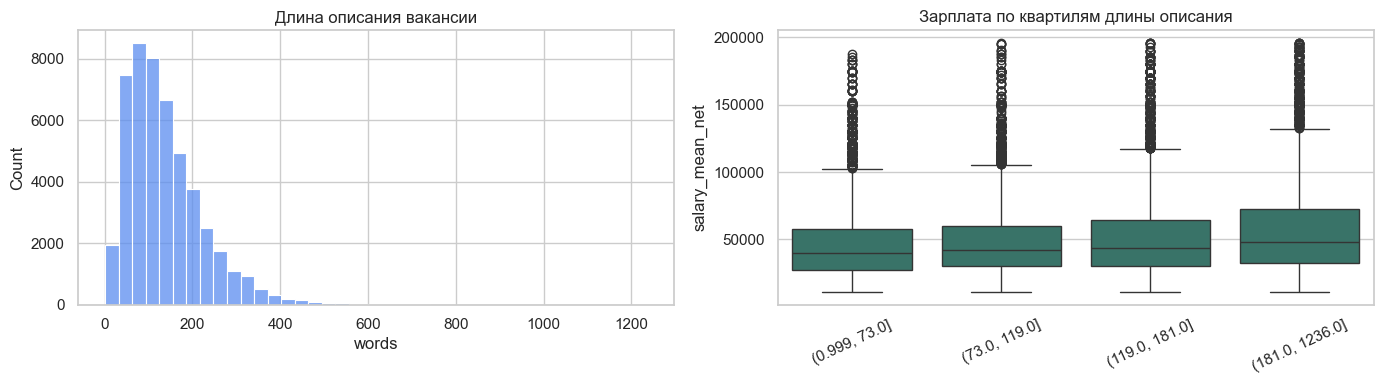

In [9]:
def count_skills(series: pd.Series) -> pd.Series:
    normalized = series.fillna("").astype(str).str.strip().str.lower()
    counts = normalized.str.split(",").map(lambda items: sum(bool(item.strip()) for item in items))
    return counts.mask(normalized.isin(["", "[]", "не указано"]), 0)


text_profile = pd.DataFrame(index=train.index)
text_profile["raw_description_chars"] = train["raw_description"].fillna("").astype(str).str.len()
text_profile["raw_description_words"] = train["raw_description"].fillna("").astype(str).str.split().str.len()
text_profile["name_words"] = train["name"].fillna("").astype(str).str.split().str.len()
text_profile["skills_count"] = count_skills(train["key_skills_name"])
text_profile["has_raw_branded_description"] = train["raw_branded_description"].notna().astype(int)
text_profile["has_city"] = train["unified_address_city"].notna().astype(int)
text_profile[TARGET] = train[TARGET]

text_stats = text_profile.drop(columns=[TARGET]).describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T
text_corr = (
    text_profile.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame("corr_with_salary")
)

description_groups = text_profile.assign(
    description_length_group=pd.qcut(
        text_profile["raw_description_words"],
        q=4,
        duplicates="drop",
    )
)
description_salary = description_groups.groupby("description_length_group", observed=True)[TARGET].agg(
    ["count", "median", "mean"]
)

display(text_stats)
display(text_corr)
display(description_salary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(text_profile["raw_description_words"], bins=40, ax=axes[0], color="#5B8DEF")
axes[0].set_title("Длина описания вакансии")
axes[0].set_xlabel("words")

sns.boxplot(
    data=description_groups,
    x="description_length_group",
    y=TARGET,
    ax=axes[1],
    color="#2F7D6E",
)
axes[1].set_title("Зарплата по квартилям длины описания")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()

Гистограмма отражает неодинаковую длину описаний вакансий. Boxplot по квартилям длины показывает слабый сдвиг зарплат вверх для более длинных описаний, но интервалы сильно пересекаются; длина текста сама по себе не является сильным предиктором.

## Вывод

1. Обучающая выборка содержит 49 051 вакансию, тестовая — 12 263 вакансии; `id` уникальны, полных дубликатов строк не обнаружено.
2. Пропуски сосредоточены в branded-описаниях (91.9%) и городе (23.5% в train, 23.0% в test); остальные поля почти полностью заполнены.
3. Целевая переменная положительная и правосторонне асимметричная: среднее — 51.1 тыс., медиана — 42.9 тыс., 99-й перцентиль — 150 тыс.
4. По IQR выбросами являются зарплаты выше 115 тыс.; таких наблюдений 2 105, или 4.29% train. Это верхний хвост, а не ошибка формата.
5. Зарплата заметно разделяется по опыту, графику, региону и профессиональной роли: например, медиана для опыта более 6 лет равна 80 тыс., для отсутствия опыта — 34.8 тыс.
6. Распределения основных категориальных признаков в train и test близки; максимальное рассмотренное TVD не превышает 0.04.
7. Текстовые мета-признаки дают дополнительный, но слабый сигнал: длина описания связана с зарплатой положительно, однако графики показывают значительное пересечение групп.
